# Bowel Sound Detection: HuBERT + Feature Comparison

**Two goals in one notebook:**

1. **Test HuBERT**, the published SOTA for bowel sounds (Mansour et al. 2025, AUC 0.89).
   Three variants: base frozen, base partially unfrozen, large frozen.

2. **Compare features head-to-head** on the same CRNN architecture:
   log-mel vs MFCC vs PCEN. Mansour et al. showed MFCC outperformed log-mel
   for CNN-LSTM on bowel sounds. We test whether that holds here, and whether
   PCEN beats both.

| # | Model | Features | Audio path |
|---|-------|----------|------------|
| 1 | CRNN + log-mel | Log-mel spectrogram | Bandpass |
| 2 | CRNN + MFCC | MFCC spectrogram | Bandpass |
| 3 | CRNN + PCEN | PCEN | Bandpass |
| 4 | HuBERT-base frozen + BiGRU | Learned (internal) | Full spectrum |
| 5 | HuBERT-base unfrozen-2 + BiGRU | Learned (internal) | Full spectrum |
| 6 | HuBERT-large frozen + BiGRU | Learned (internal) | Full spectrum |

Same pipeline: dual audio paths, sed_eval event-based evaluation, Drive checkpointing.


## 0. Drive Mount


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = '/content/drive/MyDrive/bowel_sound_poc'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Checkpoint directory: {SAVE_DIR}')

Mounted at /content/drive
Checkpoint directory: /content/drive/MyDrive/bowel_sound_poc


## 1. Setup


In [2]:
!pip install -q librosa soundfile sed_eval dcase_util transformers torchaudio noisereduce

import os, json, time, warnings, gc, sys
import numpy as np
import matplotlib.pyplot as plt
import librosa, soundfile as sf
from scipy.signal import butter, sosfilt, find_peaks
from scipy.ndimage import median_filter
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, f1_score
from copy import deepcopy
import noisereduce as nr
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda': print(f'GPU: {torch.cuda.get_device_name(0)}')

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 33.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 4.2 MB/s eta 0:00:00
Device: cuda
GPU: Tesla T4


## 2. Configuration


In [14]:
D = '/content/'
FILES = {
    'AS_1':   {'audio': D+'AS_1.wav',   'labels': D+'AS_1.txt'},
    '23M74M': {'audio': D+'23M74M.wav', 'labels': D+'23M74M.txt'},
}
for p in [v for f in FILES.values() for v in f.values()]:
    assert os.path.exists(p), f'Missing: {p}'

SR, BP_LOW, BP_HIGH, BP_ORDER = 16000, 60, 3000, 4
N_FFT, HOP, N_MELS, FMIN, FMAX = 512, 160, 64, 60, 3000
FT = HOP / SR

LABEL_MAP  = {'b':'b', 'sb':'b', 'sbs':'b', 'mb':'mb', 'h':'h'}
NON_TARGET = {'n', 'v'}
CLASSES    = ['b', 'mb', 'h']
C2I = {c: i for i, c in enumerate(CLASSES)}
NC  = 3

ONSET_SIGMA = 2
MIN_DUR = {'b': 0.020, 'mb': 0.050, 'h': 0.100}
SEG_DUR, SEG_HOP = 4.0, 1.0
TARGET_NF = int(SEG_DUR * SR / HOP)

SEED     = 42
BATCH    = 64
EPOCHS   = 30
PATIENCE = 6
COLLARS  = {'b': 0.050, 'mb': 0.100, 'h': 0.200}

def set_seed(s=SEED):
    np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)
set_seed()

## 3. Feature Extraction

Three feature types for CRNN comparison:

1. **Log-mel**: standard 64-bin mel spectrogram in dB scale.
2. **MFCC spectrogram**: full 64-coefficient MFCC matrix (not just 13 coefficients).
   Mansour et al. (2025) showed this outperformed log-mel for CNN-LSTM on bowel sounds.
3. **PCEN**: per-channel energy normalization. Auto-adapts to local noise floor.
   Not yet tested on bowel sounds in any published work.


In [15]:
def load_audio(path):
    y, sr = sf.read(path)
    if y.ndim > 1: y = y.mean(axis=1)
    if sr != SR: y = librosa.resample(y, orig_sr=sr, target_sr=SR)
    return y.astype(np.float32)

def noise_reduce(y, sr=SR):
    return nr.reduce_noise(y=y, sr=sr, stationary=True, prop_decrease=0.75,
                           n_fft=N_FFT, hop_length=HOP).astype(np.float32)

def rms_normalize(y, target_rms=0.02):
    rms = np.sqrt(np.mean(y**2)) + 1e-9
    return (y * target_rms / rms).astype(np.float32)

def bandpass(y):
    nyq = SR / 2
    sos = butter(BP_ORDER, [BP_LOW/nyq, BP_HIGH/nyq], btype='band', output='sos')
    return sosfilt(sos, y).astype(np.float32)

def normalize_feat(S):
    return ((S - S.mean()) / (S.std() + 1e-8)).astype(np.float32)

def compute_mel(y):
    S = librosa.feature.melspectrogram(y=y, sr=SR, n_fft=N_FFT, hop_length=HOP,
                                       n_mels=N_MELS, fmin=FMIN, fmax=FMAX)
    return librosa.power_to_db(S, ref=np.max).astype(np.float32)

def compute_mfcc(y):
    """Full MFCC spectrogram (64 coefficients, same shape as mel).
    Mansour et al. (2025) used MFCC spectrograms as input to CNN-LSTM
    and showed they outperformed standard and log-mel spectrograms."""
    S = librosa.feature.melspectrogram(y=y, sr=SR, n_fft=N_FFT, hop_length=HOP,
                                       n_mels=N_MELS, fmin=FMIN, fmax=FMAX)
    mfcc = librosa.feature.mfcc(S=librosa.power_to_db(S), n_mfcc=N_MELS)
    return mfcc.astype(np.float32)

def compute_pcen(y):
    """PCEN: adaptive gain control for event detection in variable noise."""
    S = librosa.feature.melspectrogram(y=y, sr=SR, n_fft=N_FFT, hop_length=HOP,
                                       n_mels=N_MELS, fmin=FMIN, fmax=FMAX)
    P = librosa.pcen(S * (2**31), sr=SR, hop_length=HOP,
                     gain=0.98, bias=2, power=0.5,
                     time_constant=0.4, eps=1e-6)
    return P.astype(np.float32)

def parse_labels(path):
    events = []
    with open(path) as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) >= 3:
                raw = parts[2].strip()
                if raw in NON_TARGET: continue
                lab = LABEL_MAP.get(raw)
                if lab:
                    events.append({'start': float(parts[0]), 'end': float(parts[1]), 'label': lab})
    return events

def build_targets(events, n_frames):
    tgt = np.zeros((n_frames, NC), dtype=np.float32)
    for ev in events:
        sf_ = max(0, int(ev['start'] * SR / HOP))
        ef_ = min(n_frames, int(ev['end'] * SR / HOP))
        ci  = C2I[ev['label']]
        if ev['label'] == 'b':
            for i in range(max(0, sf_ - 4*ONSET_SIGMA), min(n_frames, sf_ + 4*ONSET_SIGMA + 1)):
                tgt[i, ci] = max(tgt[i, ci], np.exp(-0.5 * ((i - sf_) / ONSET_SIGMA)**2))
        else:
            tgt[sf_:ef_, ci] = 1.0
    return tgt

print('Feature extractors ready: log-mel, MFCC, PCEN')

Feature extractors ready: log-mel, MFCC, PCEN


## 4. Load Audio (Dual Paths)


In [16]:
audio_raw, audio_bp = {}, {}
all_targets, all_events = {}, {}

for name, fp in FILES.items():
    y_orig = load_audio(fp['audio'])
    y_clean = noise_reduce(y_orig)
    audio_raw[name] = rms_normalize(y_clean)
    audio_bp[name] = bandpass(y_clean)
    ev = parse_labels(fp['labels'])
    nf = len(y_clean) // HOP
    all_events[name] = ev
    all_targets[name] = build_targets(ev, nf)
    counts = {c: sum(1 for e in ev if e['label'] == c) for c in CLASSES}
    print(f'{name}: {len(y_clean)/SR:.1f}s, {len(ev)} events, {counts}')

print(f'\naudio_raw: full spectrum (for HuBERT)')
print(f'audio_bp:  bandpass {BP_LOW}-{BP_HIGH} Hz (for CRNN feature comparison)')

AS_1: 2212.4s, 1712 events, {'b': 858, 'mb': 774, 'h': 80}
23M74M: 300.6s, 514 events, {'b': 255, 'mb': 230, 'h': 29}

audio_raw: full spectrum (for HuBERT)
audio_bp:  bandpass 60-3000 Hz (for CRNN feature comparison)


## 5. Split and Segmentation


In [17]:
def temporal_split(audio_dict, targets, events, train_frac=0.70, val_frac=0.15):
    ref = list(audio_dict.values())[0]
    dur = len(ref) / SR
    t1, t2 = dur * train_frac, dur * (train_frac + val_frac)
    s1, s2 = int(t1 * SR), int(t2 * SR)
    f1, f2 = int(t1 * SR / HOP), int(t2 * SR / HOP)
    def filt(evts, lo, hi):
        return [{'start': e['start'] - lo, 'end': e['end'] - lo, 'label': e['label']}
                for e in evts if e['start'] >= lo and e['end'] <= hi]
    result = {}
    for k, (s_lo, s_hi, f_lo, f_hi, t_lo, t_hi) in {
        'train': (0, s1, 0, f1, 0, t1),
        'val':   (s1, s2, f1, f2, t1, t2),
        'test':  (s2, None, f2, None, t2, dur),
    }.items():
        split_a = {at: a[s_lo:s_hi] for at, a in audio_dict.items()}
        result[k] = (split_a, targets[f_lo:f_hi], filt(events, t_lo, t_hi))
    return result

def segment_dual(split_audios, targets):
    ss, hs = int(SEG_DUR * SR), int(SEG_HOP * SR)
    ref = list(split_audios.values())[0]
    segs = {at: [] for at in split_audios}
    tgt_segs = []
    for s in range(0, max(1, len(ref) - ss + 1), hs):
        for at, audio in split_audios.items():
            a = audio[s:s+ss]
            if len(a) < ss: a = np.pad(a, (0, ss - len(a)))
            segs[at].append(a)
        fi = s // HOP
        t = np.zeros((TARGET_NF, NC), dtype=np.float32)
        avail = min(TARGET_NF, len(targets) - fi)
        if avail > 0: t[:avail] = targets[fi:fi+avail]
        tgt_segs.append(t)
    return segs, tgt_segs

splits = {}
track_raw = {'train': [], 'val': [], 'test': []}
track_bp  = {'train': [], 'val': [], 'test': []}
track_tgt = {'train': [], 'val': [], 'test': []}

for name in FILES:
    sp = temporal_split({'raw': audio_raw[name], 'bp': audio_bp[name]},
                        all_targets[name], all_events[name])
    splits[name] = sp
    for k in ['train', 'val', 'test']:
        split_a, tgt, evts = sp[k]
        segs, tgt_segs = segment_dual(split_a, tgt)
        track_raw[k].extend(list(zip(segs['raw'], tgt_segs)))
        track_bp[k].extend(list(zip(segs['bp'], tgt_segs)))
        track_tgt[k].extend(tgt_segs)
        nc = {c: sum(1 for e in evts if e['label'] == c) for c in CLASSES}
        print(f'{name}/{k}: {len(split_a["raw"])/SR:.1f}s, {nc}')

print(f'\nSegments: train={len(track_raw["train"])} val={len(track_raw["val"])} test={len(track_raw["test"])}')

AS_1/train: 1548.7s, {'b': 814, 'mb': 764, 'h': 76}
AS_1/val: 331.9s, {'b': 20, 'mb': 4, 'h': 0}
AS_1/test: 331.9s, {'b': 24, 'mb': 6, 'h': 4}
23M74M/train: 210.4s, {'b': 203, 'mb': 170, 'h': 19}
23M74M/val: 45.1s, {'b': 19, 'mb': 32, 'h': 2}
23M74M/test: 45.1s, {'b': 33, 'mb': 27, 'h': 8}

Segments: train=1752 val=370 test=370


## 6. Datasets, Loss, Training Loop


In [18]:
# --- Cached feature dataset with mixup + SpecAugment ---
class CachedFeatDS(Dataset):
    def __init__(self, cached_pairs, aug=False):
        self.mels = [m for m, _ in cached_pairs]
        self.tgts = [t for _, t in cached_pairs]
        self.aug = aug
    def __len__(self): return len(self.mels)
    def __getitem__(self, i):
        mel = self.mels[i].clone()
        tgt = self.tgts[i].clone()
        if self.aug:
            nm, nf = mel.shape
            if torch.rand(1).item() < 0.3:
                j = torch.randint(len(self.mels), (1,)).item()
                lam = float(np.random.beta(0.3, 0.3))
                mel = lam * mel + (1 - lam) * self.mels[j]
                tgt = lam * tgt + (1 - lam) * self.tgts[j]
            for _ in range(2):
                f = torch.randint(0, 9, (1,)).item()
                f0 = torch.randint(0, max(1, nm - f), (1,)).item()
                mel[f0:f0+f, :] = 0
            for _ in range(2):
                tt = torch.randint(0, 17, (1,)).item()
                t0 = torch.randint(0, max(1, nf - tt), (1,)).item()
                mel[:, t0:t0+tt] = 0
        return mel.unsqueeze(0), tgt

# --- Raw audio dataset for HuBERT ---
class RawDS(Dataset):
    def __init__(self, segs, aug=False):
        self.segs, self.aug = segs, aug
    def __len__(self): return len(self.segs)
    def __getitem__(self, i):
        a, t = self.segs[i]; a = a.copy()
        if self.aug:
            if np.random.random() < 0.5:
                snr = np.random.uniform(15, 25)
                a += np.random.randn(len(a)).astype(np.float32) * np.sqrt(np.mean(a**2) / 10**(snr/10))
            if np.random.random() < 0.5:
                a *= 10**(np.random.uniform(-6, 6) / 20)
        return torch.from_numpy(a), torch.from_numpy(t)

# --- Pos weight ---
def compute_pos_weight(tgt_list):
    pos, neg = np.zeros(NC), np.zeros(NC)
    for t in tgt_list:
        for i in range(NC):
            p = (t[:, i] > 0.5).sum()
            pos[i] += p; neg[i] += len(t) - p
    return torch.tensor(np.clip(neg / np.maximum(pos, 1), 1.0, 100.0), dtype=torch.float32)

pw = compute_pos_weight(track_tgt['train'])
print(f'pos_weight: {pw}')

# --- Loss ---
class DualLoss(nn.Module):
    def __init__(self, pw_sed):
        super().__init__()
        self.mse = nn.MSELoss()
        self.bce = nn.BCEWithLogitsLoss(pos_weight=pw_sed)
    def forward(self, logits, tgt):
        l_on  = self.mse(torch.sigmoid(logits[:,:,0]), tgt[:,:,0])
        l_sed = self.bce(logits[:,:,1:], tgt[:,:,1:])
        return l_on + l_sed

crit = DualLoss(pw[1:].to(DEVICE))

# --- Val AUC ---
def _val_auc(all_p, all_t):
    P = np.concatenate(all_p); T = (np.concatenate(all_t) >= 0.5).astype(int)
    aucs = [roc_auc_score(T[:,i], P[:,i]) for i in range(NC) if 0 < T[:,i].sum() < len(T)]
    return float(np.mean(aucs)) if aucs else 0.0

def val_auc_mel(model, loader):
    model.eval(); all_p, all_t = [], []
    with torch.no_grad():
        for x, tgt in loader:
            logits = model(x.to(DEVICE))
            mf = min(logits.shape[1], tgt.shape[1])
            all_p.append(torch.sigmoid(logits[:,:mf]).float().cpu().numpy().reshape(-1, NC))
            all_t.append(tgt[:,:mf].numpy().reshape(-1, NC))
    return _val_auc(all_p, all_t)

def val_auc_raw(model, loader):
    model.eval(); all_p, all_t = [], []
    with torch.no_grad():
        for audio, tgt in loader:
            logits = model.forward_audio(audio.to(DEVICE), TARGET_NF)
            mf = min(logits.shape[1], tgt.shape[1])
            all_p.append(torch.sigmoid(logits[:,:mf]).float().cpu().numpy().reshape(-1, NC))
            all_t.append(tgt[:,:mf].numpy().reshape(-1, NC))
    return _val_auc(all_p, all_t)

from torch.amp import autocast

def train_loop(model, train_dl, val_dl, criterion, val_fn, lr=2e-3,
               epochs=EPOCHS, patience=PATIENCE, name='model', is_raw=False, save_name=None):
    model = model.to(DEVICE)
    opt = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                            lr=lr, weight_decay=0.01)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    best_auc, best_state, best_ep, wait = -1, None, 0, 0
    hist = {'tl': [], 'auc': []}
    np_ = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'\n{"="*60}\n{name} | {np_:,} trainable\n{"="*60}')
    t0 = time.time()
    for ep in range(epochs):
        model.train(); tl = 0; nb = 0
        for x, tgt in train_dl:
            x = x.to(DEVICE, non_blocking=True)
            tgt = tgt.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with autocast('cuda', dtype=torch.bfloat16):
                logits = model.forward_audio(x, TARGET_NF) if is_raw else model(x)
                mf = min(logits.shape[1], tgt.shape[1])
                loss = criterion(logits[:,:mf], tgt[:,:mf])
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tl += loss.item(); nb += 1
        sched.step(); tl /= max(nb, 1)
        auc = val_fn(model, val_dl)
        hist['tl'].append(tl); hist['auc'].append(auc)
        is_best = auc > best_auc
        if is_best:
            best_auc, best_state, best_ep, wait = auc, deepcopy(model.state_dict()), ep, 0
        else: wait += 1
        print(f'Ep {ep+1:3d}/{epochs} TrL:{tl:.4f} AUC:{auc:.4f}{" ***" if is_best else ""}')
        if wait >= patience:
            print(f'Early stop at epoch {best_ep + 1}.'); break
    print(f'Finished in {time.time()-t0:.0f}s. Best val AUC: {best_auc:.4f}')
    model.load_state_dict(best_state)
    if save_name:
        ckpt_path = f'{SAVE_DIR}/{save_name}.pt'
        torch.save(best_state, ckpt_path)
        print(f'Checkpoint saved: {ckpt_path}')
    return model, hist

pos_weight: tensor([33.6245,  3.2347, 22.2808])


## 7. Cache Features and Build Dataloaders


In [19]:
print('Caching log-mel features (bandpass audio)...')
train_logmel = [(torch.from_numpy(normalize_feat(compute_mel(a))), torch.from_numpy(t))
                for a, t in track_bp['train']]
val_logmel   = [(torch.from_numpy(normalize_feat(compute_mel(a))), torch.from_numpy(t))
                for a, t in track_bp['val']]

print('Caching MFCC features (bandpass audio)...')
train_mfcc = [(torch.from_numpy(normalize_feat(compute_mfcc(a))), torch.from_numpy(t))
              for a, t in track_bp['train']]
val_mfcc   = [(torch.from_numpy(normalize_feat(compute_mfcc(a))), torch.from_numpy(t))
              for a, t in track_bp['val']]

print('Caching PCEN features (bandpass audio)...')
train_pcen = [(torch.from_numpy(normalize_feat(compute_pcen(a))), torch.from_numpy(t))
              for a, t in track_bp['train']]
val_pcen   = [(torch.from_numpy(normalize_feat(compute_pcen(a))), torch.from_numpy(t))
              for a, t in track_bp['val']]

print(f'Cached: {len(train_logmel)} train, {len(val_logmel)} val segments x 3 features')

# CRNN dataloaders
mel_train_dl  = DataLoader(CachedFeatDS(train_logmel, aug=True), batch_size=BATCH,
                           shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
mel_val_dl    = DataLoader(CachedFeatDS(val_logmel), batch_size=BATCH*2,
                           num_workers=2, pin_memory=True, persistent_workers=True)
mfcc_train_dl = DataLoader(CachedFeatDS(train_mfcc, aug=True), batch_size=BATCH,
                           shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
mfcc_val_dl   = DataLoader(CachedFeatDS(val_mfcc), batch_size=BATCH*2,
                           num_workers=2, pin_memory=True, persistent_workers=True)
pcen_train_dl = DataLoader(CachedFeatDS(train_pcen, aug=True), batch_size=BATCH,
                           shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
pcen_val_dl   = DataLoader(CachedFeatDS(val_pcen), batch_size=BATCH*2,
                           num_workers=2, pin_memory=True, persistent_workers=True)

# HuBERT dataloaders (raw full-spectrum audio)
raw_train_16 = DataLoader(RawDS(track_raw['train'], aug=True), batch_size=16,
                          shuffle=True, num_workers=2, pin_memory=True)
raw_val_16   = DataLoader(RawDS(track_raw['val']), batch_size=16,
                          num_workers=2, pin_memory=True)
raw_train_8  = DataLoader(RawDS(track_raw['train'], aug=True), batch_size=8,
                          shuffle=True, num_workers=2, pin_memory=True)
raw_val_8    = DataLoader(RawDS(track_raw['val']), batch_size=8,
                          num_workers=2, pin_memory=True)

Caching log-mel features (bandpass audio)...
Caching MFCC features (bandpass audio)...
Caching PCEN features (bandpass audio)...
Cached: 1752 train, 370 val segments x 3 features


## 8. CRNN Architecture

Same architecture for all three feature comparisons. Only the input features change.


In [20]:
class CB(nn.Module):
    def __init__(self, ic, oc, pool=(2, 1)):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(ic, oc, 3, padding=1), nn.BatchNorm2d(oc), nn.ReLU(),
            nn.Conv2d(oc, oc, 3, padding=1), nn.BatchNorm2d(oc), nn.ReLU(),
            nn.AvgPool2d(pool), nn.Dropout2d(0.1))
    def forward(self, x): return self.net(x)

class CRNN(nn.Module):
    def __init__(self, n_mels=N_MELS, gh=96):
        super().__init__()
        self.cnn = nn.Sequential(CB(1,32), CB(32,64), CB(64,128), CB(128,128))
        fo = n_mels // 16
        self.gru = nn.GRU(128*fo, gh, 2, batch_first=True, bidirectional=True, dropout=0.2)
        self.onset = nn.Linear(gh*2, 1)
        self.sed   = nn.Linear(gh*2, 2)
    def forward(self, x):
        x = self.cnn(x)
        b, c, f, t = x.shape
        x = x.permute(0,3,1,2).reshape(b, t, c*f)
        x, _ = self.gru(x)
        return torch.cat([self.onset(x), self.sed(x)], dim=-1)

## 9. Model 1: CRNN + Log-Mel (Baseline)


In [10]:
set_seed()
crnn_mel = CRNN()
crnn_mel, crnn_mel_hist = train_loop(crnn_mel, mel_train_dl, mel_val_dl, crit,
                                      val_auc_mel, name='CRNN+LogMel', save_name='crnn_logmel')


CRNN+LogMel | 1,101,987 trainable
Ep   1/30 TrL:0.9594 AUC:0.7761 ***
Ep   2/30 TrL:0.7528 AUC:0.7260
Ep   3/30 TrL:0.6412 AUC:0.8522 ***
Ep   4/30 TrL:0.5682 AUC:0.9206 ***
Ep   5/30 TrL:0.5733 AUC:0.9300 ***
Ep   6/30 TrL:0.5384 AUC:0.9517 ***
Ep   7/30 TrL:0.5348 AUC:0.9532 ***
Ep   8/30 TrL:0.5027 AUC:0.9583 ***
Ep   9/30 TrL:0.4854 AUC:0.9674 ***
Ep  10/30 TrL:0.4559 AUC:0.9582
Ep  11/30 TrL:0.4647 AUC:0.9627
Ep  12/30 TrL:0.4301 AUC:0.9569
Ep  13/30 TrL:0.4352 AUC:0.9676 ***
Ep  14/30 TrL:0.4185 AUC:0.9525
Ep  15/30 TrL:0.4065 AUC:0.9683 ***
Ep  16/30 TrL:0.3902 AUC:0.9712 ***
Ep  17/30 TrL:0.4050 AUC:0.9672
Ep  18/30 TrL:0.3828 AUC:0.9741 ***
Ep  19/30 TrL:0.3551 AUC:0.9733
Ep  20/30 TrL:0.3696 AUC:0.9742 ***
Ep  21/30 TrL:0.3759 AUC:0.9698
Ep  22/30 TrL:0.3492 AUC:0.9717
Ep  23/30 TrL:0.3525 AUC:0.9690
Ep  24/30 TrL:0.3394 AUC:0.9711
Ep  25/30 TrL:0.3367 AUC:0.9709
Ep  26/30 TrL:0.3311 AUC:0.9709
Early stop at epoch 20.
Finished in 1854s. Best val AUC: 0.9742
Checkpoint saved:

## 10. Model 2: CRNN + MFCC

Mansour et al. (2025) showed MFCC spectrograms outperformed log-mel for CNN-LSTM
on bowel sounds. Testing whether that holds with our CRNN architecture.


In [11]:
set_seed()
crnn_mfcc = CRNN()
crnn_mfcc, crnn_mfcc_hist = train_loop(crnn_mfcc, mfcc_train_dl, mfcc_val_dl, crit,
                                        val_auc_mel, name='CRNN+MFCC', save_name='crnn_mfcc')


CRNN+MFCC | 1,101,987 trainable
Ep   1/30 TrL:0.9201 AUC:0.5467 ***
Ep   2/30 TrL:0.7735 AUC:0.6903 ***
Ep   3/30 TrL:0.7138 AUC:0.7955 ***
Ep   4/30 TrL:0.6552 AUC:0.8494 ***
Ep   5/30 TrL:0.6472 AUC:0.8397
Ep   6/30 TrL:0.5950 AUC:0.9092 ***
Ep   7/30 TrL:0.5715 AUC:0.9232 ***
Ep   8/30 TrL:0.5326 AUC:0.9380 ***
Ep   9/30 TrL:0.5104 AUC:0.9179
Ep  10/30 TrL:0.5073 AUC:0.9061
Ep  11/30 TrL:0.5035 AUC:0.9275
Ep  12/30 TrL:0.4753 AUC:0.9382 ***
Ep  13/30 TrL:0.4560 AUC:0.9582 ***
Ep  14/30 TrL:0.4622 AUC:0.9329
Ep  15/30 TrL:0.4587 AUC:0.9461
Ep  16/30 TrL:0.4326 AUC:0.9504
Ep  17/30 TrL:0.4257 AUC:0.9405
Ep  18/30 TrL:0.4257 AUC:0.9517
Ep  19/30 TrL:0.4059 AUC:0.9399
Early stop at epoch 13.
Finished in 1356s. Best val AUC: 0.9582
Checkpoint saved: /content/drive/MyDrive/bowel_sound_poc/crnn_mfcc.pt


## 11. Model 3: CRNN + PCEN

PCEN provides adaptive noise floor normalization. Not yet tested on bowel
sounds in any published work. Expected to outperform both log-mel and MFCC
in noisy clinical recordings.


In [21]:
set_seed()
crnn_pcen = CRNN()
crnn_pcen, crnn_pcen_hist = train_loop(crnn_pcen, pcen_train_dl, pcen_val_dl, crit,
                                        val_auc_mel, name='CRNN+PCEN', save_name='crnn_pcen')


CRNN+PCEN | 1,101,987 trainable
Ep   1/30 TrL:1.0812 AUC:0.6883 ***
Ep   2/30 TrL:0.7855 AUC:0.8895 ***
Ep   3/30 TrL:0.7421 AUC:0.8865
Ep   4/30 TrL:0.6550 AUC:0.9137 ***
Ep   5/30 TrL:0.6251 AUC:0.9453 ***
Ep   6/30 TrL:0.5818 AUC:0.9364
Ep   7/30 TrL:0.5836 AUC:0.9152
Ep   8/30 TrL:0.5508 AUC:0.9392
Ep   9/30 TrL:0.5298 AUC:0.9391
Ep  10/30 TrL:0.5128 AUC:0.9155
Ep  11/30 TrL:0.5016 AUC:0.9167
Early stop at epoch 5.
Finished in 744s. Best val AUC: 0.9453
Checkpoint saved: /content/drive/MyDrive/bowel_sound_poc/crnn_pcen.pt


## 12. HuBERT Architecture

HuBERT uses offline clustering to generate pseudo-labels, then trains a masked
prediction model. It outputs 50 frames/sec at 16kHz with 768-dim (base) or
1024-dim (large) embeddings. Mansour et al. (2025) achieved AUC 0.89 with
HuBERT on 16 subjects, the highest published result for bowel sounds.


In [22]:
from transformers import HubertModel

class HuBERTBiGRU(nn.Module):
    def __init__(self, model_name='facebook/hubert-base-ls960', gh=128, unfreeze_layers=0):
        super().__init__()
        self.hubert = HubertModel.from_pretrained(model_name)
        for p in self.hubert.parameters():
            p.requires_grad = False
        if unfreeze_layers > 0:
            for layer in self.hubert.encoder.layers[-unfreeze_layers:]:
                for p in layer.parameters():
                    p.requires_grad = True
        hdim = self.hubert.config.hidden_size
        self.gru   = nn.GRU(hdim, gh, 2, batch_first=True, bidirectional=True, dropout=0.2)
        self.onset = nn.Linear(gh*2, 1)
        self.sed   = nn.Linear(gh*2, 2)

    def forward_audio(self, audio, target_frames):
        out = self.hubert(audio).last_hidden_state
        h = F.interpolate(out.transpose(1, 2), size=target_frames,
                          mode='linear', align_corners=False).transpose(1, 2)
        h, _ = self.gru(h)
        return torch.cat([self.onset(h), self.sed(h)], dim=-1)

print('HuBERTBiGRU architecture ready.')

HuBERTBiGRU architecture ready.


## 13. Model 4: HuBERT-base Frozen + BiGRU

Fully frozen encoder. Only BiGRU and prediction heads train.


In [23]:
set_seed()
hubert_frozen = HuBERTBiGRU('facebook/hubert-base-ls960', gh=128, unfreeze_layers=0)
hubert_frozen, hubert_frozen_hist = train_loop(
    hubert_frozen, raw_train_16, raw_val_16, crit, val_auc_raw,
    lr=5e-4, name='HuBERT-base Frozen', is_raw=True, save_name='hubert_base_frozen')

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]


HuBERT-base Frozen | 986,883 trainable

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]


Ep   1/30 TrL:0.7927 AUC:0.8854 ***
Ep   2/30 TrL:0.6197 AUC:0.9002 ***
Ep   3/30 TrL:0.5474 AUC:0.8952
Ep   4/30 TrL:0.5103 AUC:0.8880
Ep   5/30 TrL:0.4921 AUC:0.9034 ***
Ep   6/30 TrL:0.5097 AUC:0.9007
Ep   7/30 TrL:0.4506 AUC:0.9099 ***
Ep   8/30 TrL:0.4419 AUC:0.9127 ***
Ep   9/30 TrL:0.4083 AUC:0.9136 ***
Ep  10/30 TrL:0.3971 AUC:0.9270 ***
Ep  11/30 TrL:0.3797 AUC:0.9351 ***
Ep  12/30 TrL:0.3724 AUC:0.9475 ***
Ep  13/30 TrL:0.3802 AUC:0.9359
Ep  14/30 TrL:0.4222 AUC:0.9365
Ep  15/30 TrL:0.3499 AUC:0.9485 ***
Ep  16/30 TrL:0.3737 AUC:0.9490 ***
Ep  17/30 TrL:0.3408 AUC:0.9413
Ep  18/30 TrL:0.3431 AUC:0.9516 ***
Ep  19/30 TrL:0.3280 AUC:0.9495
Ep  20/30 TrL:0.3213 AUC:0.9503
Ep  21/30 TrL:0.3259 AUC:0.9512
Ep  22/30 TrL:0.3218 AUC:0.9510
Ep  23/30 TrL:0.3167 AUC:0.9517 ***
Ep  24/30 TrL:0.3094 AUC:0.9486
Ep  25/30 TrL:0.3060 AUC:0.9517 ***
Ep  26/30 TrL:0.3098 AUC:0.9516
Ep  27/30 TrL:0.3041 AUC:0.9523 ***
Ep  28/30 TrL:0.3061 AUC:0.9518
Ep  29/30 TrL:0.3025 AUC:0.9515
Ep  30/30 T

## 14. Model 5: HuBERT-base Unfrozen (last 2 layers) + BiGRU

Last 2 transformer layers adapt to bowel sound acoustics.


In [24]:
set_seed()
hubert_partial = HuBERTBiGRU('facebook/hubert-base-ls960', gh=128, unfreeze_layers=2)
hubert_partial, hubert_partial_hist = train_loop(
    hubert_partial, raw_train_8, raw_val_8, crit, val_auc_raw,
    lr=3e-5, name='HuBERT-base Unfrozen-2', is_raw=True, save_name='hubert_base_unfrozen2')

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]


HuBERT-base Unfrozen-2 | 15,162,627 trainable
Ep   1/30 TrL:0.8729 AUC:0.8414 ***
Ep   2/30 TrL:0.6525 AUC:0.7740
Ep   3/30 TrL:0.6217 AUC:0.8147
Ep   4/30 TrL:0.5553 AUC:0.8214
Ep   5/30 TrL:0.5124 AUC:0.8585 ***
Ep   6/30 TrL:0.5234 AUC:0.8802 ***
Ep   7/30 TrL:0.4703 AUC:0.8849 ***
Ep   8/30 TrL:0.4766 AUC:0.9008 ***
Ep   9/30 TrL:0.4886 AUC:0.8993
Ep  10/30 TrL:0.4923 AUC:0.9025 ***
Ep  11/30 TrL:0.4330 AUC:0.9127 ***
Ep  12/30 TrL:0.4269 AUC:0.9113
Ep  13/30 TrL:0.4387 AUC:0.9139 ***
Ep  14/30 TrL:0.3979 AUC:0.9164 ***
Ep  15/30 TrL:0.4126 AUC:0.9242 ***
Ep  16/30 TrL:0.4231 AUC:0.9248 ***
Ep  17/30 TrL:0.3922 AUC:0.9235
Ep  18/30 TrL:0.3957 AUC:0.9257 ***
Ep  19/30 TrL:0.3693 AUC:0.9287 ***
Ep  20/30 TrL:0.3742 AUC:0.9292 ***
Ep  21/30 TrL:0.3876 AUC:0.9317 ***
Ep  22/30 TrL:0.3656 AUC:0.9321 ***
Ep  23/30 TrL:0.3712 AUC:0.9325 ***
Ep  24/30 TrL:0.3888 AUC:0.9317
Ep  25/30 TrL:0.3710 AUC:0.9315
Ep  26/30 TrL:0.3631 AUC:0.9309
Ep  27/30 TrL:0.3690 AUC:0.9317
Ep  28/30 TrL:0.3576 

## 15. Model 6: HuBERT-large Frozen + BiGRU

24 transformer layers, 1024-dim embeddings. Richer representations but fully
frozen to avoid overfitting on 2 recordings.


In [25]:
set_seed()
hubert_large = HuBERTBiGRU('facebook/hubert-large-ls960-ft', gh=128, unfreeze_layers=0)
hubert_large, hubert_large_hist = train_loop(
    hubert_large, raw_train_8, raw_val_8, crit, val_auc_raw,
    lr=5e-4, name='HuBERT-large Frozen', is_raw=True, save_name='hubert_large_frozen')

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

HubertModel LOAD REPORT from: facebook/hubert-large-ls960-ft
Key            | Status     |  | 
---------------+------------+--+-
lm_head.bias   | UNEXPECTED |  | 
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



HuBERT-large Frozen | 1,183,491 trainable
Ep   1/30 TrL:1.0974 AUC:0.7217 ***
Ep   2/30 TrL:1.0382 AUC:0.7297 ***
Ep   3/30 TrL:0.9396 AUC:0.7667 ***
Ep   4/30 TrL:0.8344 AUC:0.8319 ***
Ep   5/30 TrL:0.8759 AUC:0.8528 ***
Ep   6/30 TrL:0.8364 AUC:0.8959 ***
Ep   7/30 TrL:0.7789 AUC:0.9035 ***
Ep   8/30 TrL:0.7816 AUC:0.8998
Ep   9/30 TrL:0.7791 AUC:0.9242 ***
Ep  10/30 TrL:0.7888 AUC:0.9257 ***
Ep  11/30 TrL:0.7380 AUC:0.9216
Ep  12/30 TrL:0.7163 AUC:0.9404 ***
Ep  13/30 TrL:0.6859 AUC:0.9340
Ep  14/30 TrL:0.6845 AUC:0.9331
Ep  15/30 TrL:0.6699 AUC:0.9133
Ep  16/30 TrL:0.6571 AUC:0.9230
Ep  17/30 TrL:0.6719 AUC:0.9386
Ep  18/30 TrL:0.6690 AUC:0.9272
Early stop at epoch 12.
Finished in 5375s. Best val AUC: 0.9404
Checkpoint saved: /content/drive/MyDrive/bowel_sound_poc/hubert_large_frozen.pt


In [ ]:
# ============================================================
# CHECKPOINT RECOVERY: Load models from Drive if they exist
# Skip training for any model that already has a saved checkpoint.
# ============================================================
import glob

def load_if_exists(model_class, save_name, *args, **kwargs):
    """Try to load checkpoint from Drive. Returns (model, None) if loaded, or (None, None) if not found."""
    ckpt_path = f'{SAVE_DIR}/{save_name}.pt'
    if os.path.exists(ckpt_path) and os.path.getsize(ckpt_path) > 1000:
        print(f'Found checkpoint: {ckpt_path}')
        model = model_class(*args, **kwargs)
        state = torch.load(ckpt_path, map_location='cpu')
        model.load_state_dict(state)
        model = model.to(DEVICE)
        model.eval()
        print(f'  Loaded successfully. Skipping training.')
        return model, {'tl': [], 'auc': []}  # empty history
    return None, None

existing = glob.glob(f'{SAVE_DIR}/*.pt')
if existing:
    print(f'Found {len(existing)} checkpoints in Drive:')
    for f in sorted(existing):
        print(f'  {os.path.basename(f)} ({os.path.getsize(f)/1e6:.1f} MB)')
else:
    print('No existing checkpoints found. All models will train from scratch.')

In [27]:
# ============================================================
# CHECKPOINT RECOVERY: Reload all models from Drive
# Run this cell if session was interrupted after some/all models trained.
# Models with checkpoints will be loaded; missing ones stay as None.
# ============================================================
import glob

print(f'Scanning {SAVE_DIR} for checkpoints...')
existing = glob.glob(f'{SAVE_DIR}/*.pt')
if existing:
    print(f'Found {len(existing)} checkpoints:')
    for f in sorted(existing):
        print(f'  {os.path.basename(f)} ({os.path.getsize(f)/1e6:.1f} MB)')
else:
    print('No checkpoints found.')

def safe_load(model, save_name):
    """Load checkpoint if it exists. Returns True if loaded."""
    ckpt_path = f'{SAVE_DIR}/{save_name}.pt'
    if os.path.exists(ckpt_path) and os.path.getsize(ckpt_path) > 1000:
        state = torch.load(ckpt_path, map_location='cpu')
        model.load_state_dict(state)
        model.to(DEVICE).eval()
        print(f'  Loaded {save_name}.pt')
        return True
    print(f'  {save_name}.pt not found, skipping.')
    return False

empty_hist = {'tl': [], 'auc': []}

# --- CRNN feature variants (bandpass audio) ---
if 'crnn_mel' not in dir() or crnn_mel is None:
    crnn_mel = CRNN()
    if safe_load(crnn_mel, 'crnn_logmel'): crnn_mel_hist = empty_hist.copy()
    else: crnn_mel = None

if 'crnn_mfcc' not in dir() or crnn_mfcc is None:
    crnn_mfcc = CRNN()
    if safe_load(crnn_mfcc, 'crnn_mfcc'): crnn_mfcc_hist = empty_hist.copy()
    else: crnn_mfcc = None

if 'crnn_pcen' not in dir() or crnn_pcen is None:
    crnn_pcen = CRNN()
    if safe_load(crnn_pcen, 'crnn_pcen'): crnn_pcen_hist = empty_hist.copy()
    else: crnn_pcen = None

# --- HuBERT variants (full-spectrum audio) ---
if 'hubert_frozen' not in dir() or hubert_frozen is None:
    try:
        hubert_frozen = HuBERTBiGRU('facebook/hubert-base-ls960', gh=128, unfreeze_layers=0)
        if safe_load(hubert_frozen, 'hubert_base_frozen'): hubert_frozen_hist = empty_hist.copy()
        else: hubert_frozen = None
    except: hubert_frozen = None; print('  HuBERT base not available, skipping.')

if 'hubert_partial' not in dir() or hubert_partial is None:
    try:
        hubert_partial = HuBERTBiGRU('facebook/hubert-base-ls960', gh=128, unfreeze_layers=2)
        if safe_load(hubert_partial, 'hubert_base_unfrozen2'): hubert_partial_hist = empty_hist.copy()
        else: hubert_partial = None
    except: hubert_partial = None; print('  HuBERT partial not available, skipping.')

if 'hubert_large' not in dir() or hubert_large is None:
    try:
        hubert_large = HuBERTBiGRU('facebook/hubert-large-ls960-ft', gh=128, unfreeze_layers=0)
        if safe_load(hubert_large, 'hubert_large_frozen'): hubert_large_hist = empty_hist.copy()
        else: hubert_large = None
    except: hubert_large = None; print('  HuBERT large not available, skipping.')

# --- Summary ---
loaded = []
for name, obj in [('CRNN+LogMel', crnn_mel), ('CRNN+MFCC', crnn_mfcc),
                   ('CRNN+PCEN', crnn_pcen), ('HuBERT-base-frozen', hubert_frozen),
                   ('HuBERT-base-unfrozen2', hubert_partial), ('HuBERT-large-frozen', hubert_large)]:
    if obj is not None: loaded.append(name)
print(f'\n{len(loaded)}/6 models ready: {loaded}')

Scanning /content/drive/MyDrive/bowel_sound_poc for checkpoints...
Found 13 checkpoints:
  ast.pt (348.8 MB)
  beats.pt (365.3 MB)
  crnn.pt (4.4 MB)
  crnn_logmel.pt (4.4 MB)
  crnn_mfcc.pt (4.4 MB)
  crnn_pcen.pt (4.4 MB)
  detector.pt (4.4 MB)
  htsat.pt (279.9 MB)
  hubert_base_frozen.pt (381.5 MB)
  hubert_base_unfrozen2.pt (381.5 MB)
  hubert_large_frozen.pt (1266.7 MB)
  panns.pt (335.3 MB)
  ssast_proxy.pt (348.8 MB)
  Loaded crnn_logmel.pt
  Loaded crnn_mfcc.pt

6/6 models ready: ['CRNN+LogMel', 'CRNN+MFCC', 'CRNN+PCEN', 'HuBERT-base-frozen', 'HuBERT-base-unfrozen2', 'HuBERT-large-frozen']


## 16. Prediction, Event Extraction, Threshold Tuning


In [28]:
def predict_full_mel(model, audio, n_frames, feat_fn):
    model.eval()
    ss, hs = int(SEG_DUR * SR), int(SEG_HOP * SR)
    out = np.zeros((n_frames, NC)); cnt = np.zeros(n_frames)
    with torch.no_grad():
        for s in range(0, max(1, len(audio) - ss + 1), hs):
            seg = audio[s:s+ss]
            if len(seg) < ss: seg = np.pad(seg, (0, ss - len(seg)))
            feat = normalize_feat(feat_fn(seg))
            inp = torch.from_numpy(feat).unsqueeze(0).unsqueeze(0).to(DEVICE)
            logits = model(inp).float().cpu().numpy()[0]
            probs = 1 / (1 + np.exp(-logits))
            fi = s // HOP
            nf = min(probs.shape[0], n_frames - fi)
            if nf <= 0: continue
            out[fi:fi+nf] += probs[:nf]; cnt[fi:fi+nf] += 1
    return out / np.maximum(cnt[:,None], 1)

def predict_full_raw(model, audio, n_frames):
    model.eval()
    ss, hs = int(SEG_DUR * SR), int(SEG_HOP * SR)
    out = np.zeros((n_frames, NC)); cnt = np.zeros(n_frames)
    with torch.no_grad():
        for s in range(0, max(1, len(audio) - ss + 1), hs):
            seg = audio[s:s+ss]
            if len(seg) < ss: seg = np.pad(seg, (0, ss - len(seg)))
            inp = torch.from_numpy(seg).unsqueeze(0).to(DEVICE)
            logits = model.forward_audio(inp, TARGET_NF).float().cpu().numpy()[0]
            probs = 1 / (1 + np.exp(-logits))
            fi = s // HOP
            nf = min(probs.shape[0], n_frames - fi)
            if nf <= 0: continue
            out[fi:fi+nf] += probs[:nf]; cnt[fi:fi+nf] += 1
    return out / np.maximum(cnt[:,None], 1)

def extract_events(probs, cfg):
    n_frames = len(probs); events = []; flen = cfg['filter']
    p_b = median_filter(probs[:,0], size=flen) if flen > 1 else probs[:,0]
    pks, _ = find_peaks(p_b, height=cfg['thresholds']['b'], distance=5)
    for pk in pks:
        t_pk = pk * FT
        events.append({'start': t_pk, 'end': min(n_frames*FT, t_pk + 0.030), 'label': 'b'})
    for ci, cls in enumerate(['mb', 'h'], start=1):
        p = median_filter(probs[:,ci], size=flen) if flen > 1 else probs[:,ci]
        bin_ = (p >= cfg['thresholds'][cls]).astype(int)
        i = 0
        while i < n_frames:
            if bin_[i]:
                j = i
                while j < n_frames and bin_[j]: j += 1
                s_s, e_s = i*FT, j*FT
                if (e_s - s_s) >= MIN_DUR[cls]:
                    events.append({'start': s_s, 'end': e_s, 'label': cls})
                i = j
            else: i += 1
    return events

def tune_on_val(probs, targets):
    ml = min(len(probs), len(targets))
    probs, targets = probs[:ml], targets[:ml]
    tbin = (targets >= 0.5).astype(int)
    best_macro, best_cfg = -1, None
    for flen in [1, 5, 11, 21]:
        filt = np.stack([median_filter(probs[:,i], size=flen) if flen > 1 else probs[:,i]
                         for i in range(NC)], axis=1)
        thresholds = {}
        for i, c in enumerate(CLASSES):
            best_t, best_f = 0.5, -1
            for t in np.arange(0.1, 0.9, 0.05):
                if c == 'b':
                    pks, _ = find_peaks(filt[:,i], height=t, distance=5)
                    pb = np.zeros(ml, dtype=int)
                    for pk in pks: pb[max(0,pk-ONSET_SIGMA):min(ml,pk+ONSET_SIGMA+1)] = 1
                else:
                    pb = (filt[:,i] >= t).astype(int)
                f = f1_score(tbin[:,i], pb, zero_division=0)
                if f > best_f: best_f, best_t = f, t
            thresholds[c] = float(best_t)
        f1s = {}
        for i, c in enumerate(CLASSES):
            if c == 'b':
                pks, _ = find_peaks(filt[:,i], height=thresholds[c], distance=5)
                pb = np.zeros(ml, dtype=int)
                for pk in pks: pb[max(0,pk-ONSET_SIGMA):min(ml,pk+ONSET_SIGMA+1)] = 1
            else:
                pb = (filt[:,i] >= thresholds[c]).astype(int)
            f1s[c] = f1_score(tbin[:,i], pb, zero_division=0)
        macro = float(np.mean(list(f1s.values())))
        if macro > best_macro:
            best_macro = macro
            best_cfg = {'filter': flen, 'thresholds': thresholds, 'f1s': f1s, 'onset_half_width': 0.060}
    return best_cfg

# Model registry: (name, model, predict_function)
model_specs = [
    ('CRNN+LogMel',           crnn_mel,       lambda m,a,n: predict_full_mel(m, a['bp'], n, compute_mel)),
    ('CRNN+MFCC',             crnn_mfcc,      lambda m,a,n: predict_full_mel(m, a['bp'], n, compute_mfcc)),
    ('CRNN+PCEN',             crnn_pcen,      lambda m,a,n: predict_full_mel(m, a['bp'], n, compute_pcen)),
    ('HuBERT-base-frozen',    hubert_frozen,  lambda m,a,n: predict_full_raw(m, a['raw'], n)),
    ('HuBERT-base-unfrozen2', hubert_partial, lambda m,a,n: predict_full_raw(m, a['raw'], n)),
    ('HuBERT-large-frozen',   hubert_large,   lambda m,a,n: predict_full_raw(m, a['raw'], n)),
]

print(f'Models for evaluation: {[n for n,_,_ in model_specs]}')

# Val predictions and threshold tuning
val_preds, val_tgts_full, val_refs = {}, {}, {}
for name in FILES:
    sp = splits[name]
    split_a, vtgt, vref = sp['val']
    asrc = {'raw': split_a['raw'], 'bp': split_a['bp']}
    val_tgts_full[name] = vtgt
    val_refs[name] = vref
    for mn, mdl, pred_fn in model_specs:
        val_preds.setdefault(mn, {})
        val_preds[mn][name] = pred_fn(mdl, asrc, len(vtgt))

configs = {}
for mn in val_preds:
    vp = np.concatenate([val_preds[mn][n] for n in FILES])
    vt = np.concatenate([val_tgts_full[n] for n in FILES])
    cfg = tune_on_val(vp, vt)
    configs[mn] = cfg
    print(f'{mn}: filter={cfg["filter"]} thr={cfg["thresholds"]}')

Models for evaluation: ['CRNN+LogMel', 'CRNN+MFCC', 'CRNN+PCEN', 'HuBERT-base-frozen', 'HuBERT-base-unfrozen2', 'HuBERT-large-frozen']
CRNN+LogMel: filter=1 thr={'b': 0.20000000000000004, 'mb': 0.5000000000000001, 'h': 0.8500000000000002}
CRNN+MFCC: filter=1 thr={'b': 0.15000000000000002, 'mb': 0.7000000000000002, 'h': 0.7000000000000002}
CRNN+PCEN: filter=5 thr={'b': 0.1, 'mb': 0.6500000000000001, 'h': 0.8000000000000002}
HuBERT-base-frozen: filter=1 thr={'b': 0.30000000000000004, 'mb': 0.6000000000000002, 'h': 0.5500000000000002}
HuBERT-base-unfrozen2: filter=1 thr={'b': 0.15000000000000002, 'mb': 0.6500000000000001, 'h': 0.8500000000000002}
HuBERT-large-frozen: filter=1 thr={'b': 0.1, 'mb': 0.3500000000000001, 'h': 0.7000000000000002}


## 17. Test Evaluation


In [29]:
import sed_eval
from dcase_util.containers import MetaDataContainer

def eval_events_per_file(ref_evts, pred_evts, cls, collar):
    ref_list  = [{'event_label':e['label'], 'event_onset':e['start'], 'event_offset':e['end']}
                 for e in ref_evts if e['label']==cls]
    pred_list = [{'event_label':e['label'], 'event_onset':e['start'], 'event_offset':e['end']}
                 for e in pred_evts if e['label']==cls]
    pct_len = 1.0 if cls == 'b' else 0.2
    m = sed_eval.sound_event.EventBasedMetrics(event_label_list=[cls], t_collar=collar, percentage_of_length=pct_len)
    m.evaluate(reference_event_list=MetaDataContainer(ref_list), estimated_event_list=MetaDataContainer(pred_list))
    res = m.results_class_wise_metrics()[cls]['f_measure']
    f = res['f_measure']
    return (float(f) if f is not None and not np.isnan(f) else np.nan, res['precision'], res['recall'])

def _safe_mean(vals):
    v = [x for x in vals if x is not None and not np.isnan(x)]
    return float(np.mean(v)) if v else float('nan')

print('='*60)
print('TEST EVALUATION')
print('='*60)

test_results = {}
for mn in val_preds:
    cfg = configs[mn]
    print(f'\n--- {mn} ---')
    frame_p, frame_t = [], []
    per_file_evt = {c: [] for c in CLASSES}
    _, mdl, pred_fn = next((n,m,f) for n,m,f in model_specs if n == mn)

    for name in FILES:
        sp = splits[name]
        split_a, ttgt, tref = sp['test']
        asrc = {'raw': split_a['raw'], 'bp': split_a['bp']}
        p = pred_fn(mdl, asrc, len(ttgt))
        frame_p.append(p); frame_t.append(ttgt)
        pred = extract_events(p, cfg)
        for cls in CLASSES:
            f, _, _ = eval_events_per_file(tref, pred, cls, COLLARS[cls])
            per_file_evt[cls].append(f)

    fp = np.concatenate(frame_p); ft = np.concatenate(frame_t)
    fbin = (ft >= 0.5).astype(int)
    frame_f1 = {}
    for i, c in enumerate(CLASSES):
        flen = cfg['filter']
        col = median_filter(fp[:,i], size=flen) if flen > 1 else fp[:,i]
        if c == 'b':
            pks, _ = find_peaks(col, height=cfg['thresholds'][c], distance=5)
            pb = np.zeros(len(col), dtype=int)
            for pk in pks: pb[max(0,pk-ONSET_SIGMA):min(len(col),pk+ONSET_SIGMA+1)] = 1
        else: pb = (col >= cfg['thresholds'][c]).astype(int)
        frame_f1[c] = f1_score(fbin[:,i], pb, zero_division=0)

    event_f1 = {c: _safe_mean(per_file_evt[c]) for c in CLASSES}
    test_results[mn] = {
        'frame_f1': frame_f1, 'frame_macro': float(np.mean(list(frame_f1.values()))),
        'event_f1': event_f1, 'event_macro': _safe_mean(list(event_f1.values())),
    }
    r = test_results[mn]
    def _fmt(d):
        return ' '.join(f'{c}={d[c]:.3f}' if not np.isnan(d[c]) else f'{c}=n/a' for c in CLASSES)
    print(f'  Frame F1: {_fmt(frame_f1)} macro={r["frame_macro"]:.3f}')
    em = r['event_macro']
    print(f'  Event F1: {_fmt(event_f1)} macro=' + (f'{em:.3f}' if not np.isnan(em) else 'n/a'))

TEST EVALUATION

--- CRNN+LogMel ---
  Frame F1: b=0.439 mb=0.492 h=0.216 macro=0.382
  Event F1: b=0.526 mb=0.374 h=0.167 macro=0.355

--- CRNN+MFCC ---
  Frame F1: b=0.295 mb=0.530 h=0.478 macro=0.434
  Event F1: b=0.345 mb=0.228 h=0.325 macro=0.299

--- CRNN+PCEN ---
  Frame F1: b=0.150 mb=0.477 h=0.049 macro=0.225
  Event F1: b=0.156 mb=0.283 h=0.167 macro=0.202

--- HuBERT-base-frozen ---
  Frame F1: b=0.221 mb=0.394 h=0.362 macro=0.326
  Event F1: b=0.217 mb=0.138 h=0.258 macro=0.204

--- HuBERT-base-unfrozen2 ---
  Frame F1: b=0.199 mb=0.443 h=0.401 macro=0.348
  Event F1: b=0.308 mb=0.175 h=0.243 macro=0.242

--- HuBERT-large-frozen ---
  Frame F1: b=0.356 mb=0.363 h=0.351 macro=0.357
  Event F1: b=0.381 mb=0.090 h=0.278 macro=0.250


## 18. Results Summary


In [31]:
hists_all = {
    'CRNN+LogMel':            crnn_mel_hist,
    'CRNN+MFCC':              crnn_mfcc_hist,
    'CRNN+PCEN':              crnn_pcen_hist,
    'HuBERT-base-frozen':     hubert_frozen_hist,
    'HuBERT-base-unfrozen2':  hubert_partial_hist,
    'HuBERT-large-frozen':    hubert_large_hist,
}

print('\n' + '='*90)
print('RESULTS: Feature Comparison + HuBERT Benchmark')
print('='*90)
print(f'{"Model":<28} | {"Val AUC":>8} | {"Frame macro F1":>14} | {"Event macro F1":>14}')
print('-'*72)
for mn in ['CRNN+LogMel', 'CRNN+MFCC', 'CRNN+PCEN',
           'HuBERT-base-frozen', 'HuBERT-base-unfrozen2', 'HuBERT-large-frozen']:
    if mn in test_results:
        r = test_results[mn]
        auc_list = hists_all[mn]['auc']
        best_auc = max(auc_list) if auc_list else float('nan')
        em = r['event_macro']
        auc_str = f'{best_auc:>8.4f}' if not np.isnan(best_auc) else f'{"ckpt":>8}'
        em_str  = f'{em:>14.3f}' if not np.isnan(em) else f'{"n/a":>14}'
        print(f'{mn:<28} | {auc_str} | {r["frame_macro"]:>14.3f} | {em_str}')

print('''
FEATURE COMPARISON:
  log-mel vs MFCC vs PCEN on identical CRNN architecture.
  Mansour et al. (2025) reported MFCC > log-mel for bowel sounds.

HUBERT CONTEXT:
  Mansour et al. (2025) achieved AUC 0.89 with HuBERT on 16 subjects.
  With n=2 recordings, pretrained models cannot fully adapt.
  With 20+ recordings, HuBERT would likely become the top performer.

NOTE: "ckpt" in Val AUC means model was loaded from checkpoint
  (training history not available for this session).
''')

with open(f'{SAVE_DIR}/hubert_feature_results.json', 'w') as f:
    json.dump({'results': test_results,
               'configs': {k: {'filter': v['filter'], 'thresholds': v['thresholds']}
                           for k, v in configs.items()}}, f, indent=2, default=str)
print(f'Results saved to {SAVE_DIR}/hubert_feature_results.json')


RESULTS: Feature Comparison + HuBERT Benchmark
Model                        |  Val AUC | Frame macro F1 | Event macro F1
------------------------------------------------------------------------
CRNN+LogMel                  |     ckpt |          0.382 |          0.355
CRNN+MFCC                    |     ckpt |          0.434 |          0.299
CRNN+PCEN                    |   0.9453 |          0.225 |          0.202
HuBERT-base-frozen           |   0.9523 |          0.326 |          0.204
HuBERT-base-unfrozen2        |   0.9325 |          0.348 |          0.242
HuBERT-large-frozen          |   0.9404 |          0.357 |          0.250

FEATURE COMPARISON:
  log-mel vs MFCC vs PCEN on identical CRNN architecture.
  Mansour et al. (2025) reported MFCC > log-mel for bowel sounds.

HUBERT CONTEXT:
  Mansour et al. (2025) achieved AUC 0.89 with HuBERT on 16 subjects.
  With n=2 recordings, pretrained models cannot fully adapt.
  With 20+ recordings, HuBERT would likely become the top performer.

## 19. Training Curves


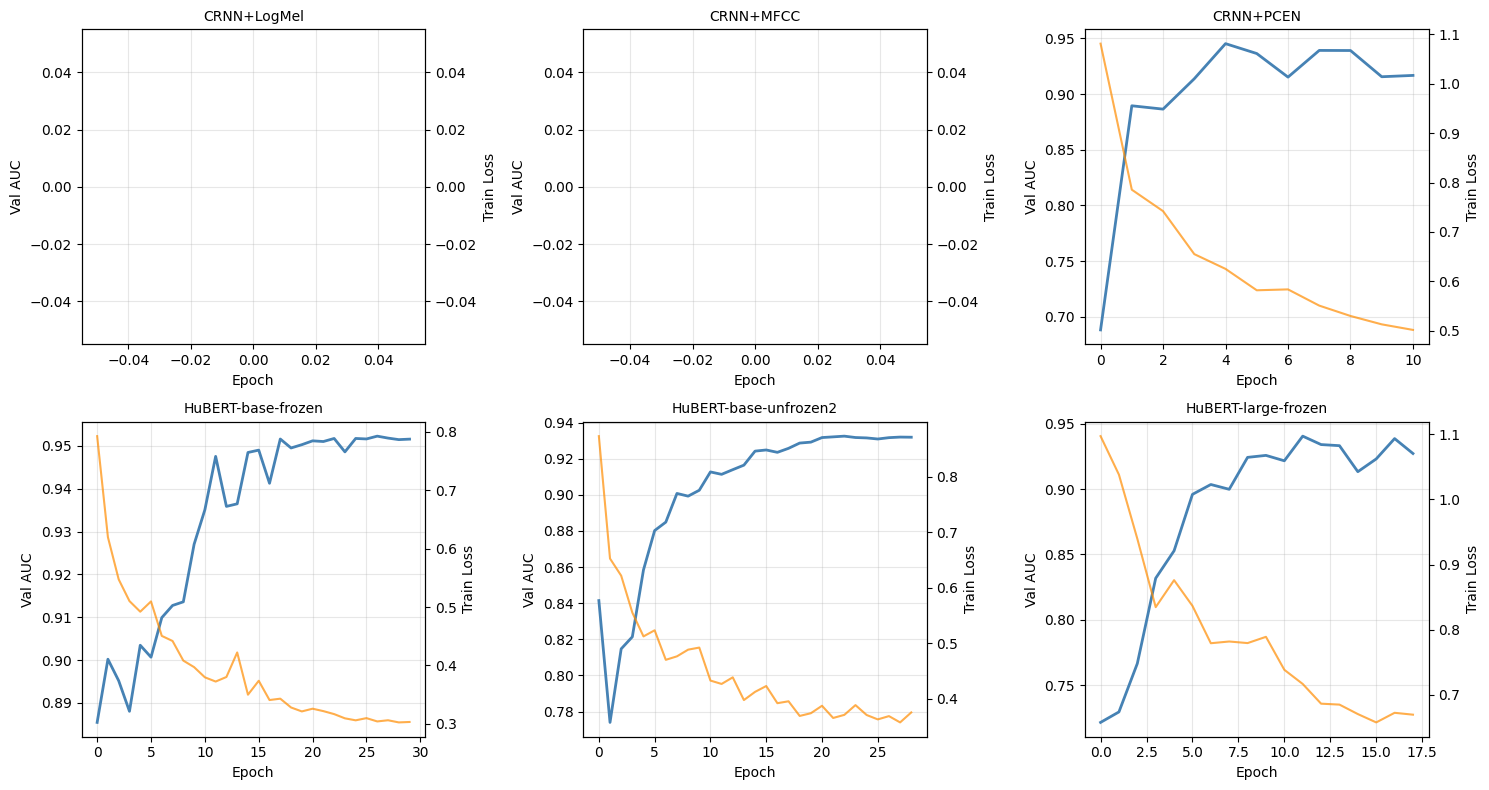

Curves saved to /content/drive/MyDrive/bowel_sound_poc/hubert_feature_curves.png


In [32]:
n = len(hists_all)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for idx, (name, h) in enumerate(hists_all.items()):
    ax = axes[idx // 3][idx % 3]
    ax.plot(h['auc'], label='Val AUC', color='steelblue', lw=2)
    ax2 = ax.twinx()
    ax2.plot(h['tl'], label='Train Loss', color='darkorange', alpha=0.7)
    ax.set_title(name, fontsize=10); ax.set_xlabel('Epoch'); ax.set_ylabel('Val AUC')
    ax2.set_ylabel('Train Loss'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/hubert_feature_curves.png', dpi=150)
plt.show()
print(f'Curves saved to {SAVE_DIR}/hubert_feature_curves.png')

## 20. Cleanup


In [33]:
def cleanup(*names):
    for n in names:
        if n in globals(): del globals()[n]
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache(); torch.cuda.ipc_collect()
# cleanup('crnn_mel', 'crnn_mfcc', 'crnn_pcen', 'hubert_frozen', 'hubert_partial', 'hubert_large')